In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')
df.head()               

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df.iloc[:,0:8]
y = df.iloc[:,-1]

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


2026-03-05 12:17:02.085697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772713022.407678      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772713022.495697      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772713023.230301      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772713023.230374      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772713023.230377      55 computation_placer.cc:177] computation placer alr

Just doing it

In [7]:
model  = Sequential()
model.add(Dense(32,activation='relu',input_dim=8))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-05 12:17:33.947312: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [9]:
model.fit(X_train,y_train,batch_size=32,epochs=100,verbose=False,validation_data=(X_test,y_test))

# Keras Tuner

In [10]:
pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [11]:
import keras_tuner as kt
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# How to Select a appropriate Optimizer

In [12]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(32,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))
    optmizer = hp.Choice('optimizer',values=['adam','adadelta','rmsprop','sgd'])
    model.compile(optimizer = optmizer,loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [13]:
tuner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=5)


In [14]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 4 Complete [00h 00m 02s]
val_accuracy: 0.7142857313156128

Best val_accuracy So Far: 0.7207792401313782
Total elapsed time: 00h 00m 10s


In [15]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'adam'}

In [16]:
model = tuner.get_best_models(num_models=1)[0]
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.fit(X_train,y_train,epochs=100,initial_epoch=6,batch_size=32,validation_data=(X_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7857 - loss: 0.4915 - val_accuracy: 0.7468 - val_loss: 0.5387
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7823 - loss: 0.4774 - val_accuracy: 0.7338 - val_loss: 0.5333
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7889 - loss: 0.4687 - val_accuracy: 0.7273 - val_loss: 0.5288
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7655 - loss: 0.4858 - val_accuracy: 0.7273 - val_loss: 0.5277
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7718 - loss: 0.4892 - val_accuracy: 0.7403 - val_loss: 0.5258
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7823 - loss: 0.4504 - val_accuracy: 0.7403 - val_loss: 0.5258
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7882 - loss: 0.4404 - val_accuracy: 0.7468 - val_loss: 0.5248
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7945 - loss: 0.4324 - val_accuracy: 0.74

# NO. of nodes in the layer

In [18]:
def build_model(hp):
    model = Sequential()
    # inital,final,step - will build all models and give the best result
    units = hp.Int('units',min_value=8,max_value=128,step=8)
    model.add(Dense(units=units,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])
    return model
    

In [19]:
tuner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=5,
                        directory='mydir')

In [20]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 5 Complete [00h 00m 02s]
val_accuracy: 0.7077922224998474

Best val_accuracy So Far: 0.7532467246055603
Total elapsed time: 00h 00m 10s


In [21]:
tuner.get_best_hyperparameters()[0].values

{'units': 104}

In [22]:
model = tuner.get_best_models(num_models=1)[0]

In [23]:
model.fit(X_train,y_train,epochs=100,initial_epoch=6,verbose=False,validation_data=(X_test,y_test))

# How to select the number of layers

In [24]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(96,activation='relu',input_dim=8))
    for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
        model.add(Dense(96,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [25]:
tuner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=5,directory='best_num_layers1')

In [33]:
tuner.search(X_train,y_train,validation_data=(X_test,y_test),epochs=5)

In [27]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 6}

In [28]:
model = tuner.get_best_models(num_models=1)[0]

In [34]:

model.fit(X_train,y_train,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8650 - loss: 0.3293 - val_accuracy: 0.7338 - val_loss: 0.6182
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8366 - loss: 0.3723 - val_accuracy: 0.7338 - val_loss: 0.5852
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8572 - loss: 0.3297 - val_accuracy: 0.7403 - val_loss: 0.5906
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8644 - loss: 0.2997 - val_accuracy: 0.7078 - val_loss: 0.6461
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8500 - loss: 0.3448 - val_accuracy: 0.7013 - val_loss: 0.6226
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8681 - loss: 0.3284 - val_accuracy: 0.7403 - val_loss: 0.6147
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8655 - loss: 0.3173 - val_accuracy: 0.6558 - val_loss: 0.8989
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8336 - loss: 0.3468 - val_accuracy: 0.740

# All in One model

In [38]:
def build_model(hp):
    model = Sequential()
    counter = 0
    for i in range(hp.Int('num_layers',min_value=1, max_value=10,)):
        if(counter==0):
            model.add(Dense(hp.Int('no.of_nodes'+str(i),min_value=8,max_value=128,step=8),activation=hp.Choice('optimise',values=['sigmoid','relu','tanh','elu']),input_dim=8))
        else:
             model.add(Dense(hp.Int('no.of_nodes'+str(i),min_value=8,max_value=128,step=8),activation=hp.Choice('optimise',values=['sigmoid','relu','tanh','elu'])))
        counter+=1
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer=hp.Choice('opti',values=['adam','rmsprop','sgd','nadam','adadelta']),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return model

In [41]:
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=5,
                        directory='final'
                       )

In [42]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.4025973975658417

Best val_accuracy So Far: 0.7467532753944397
Total elapsed time: 00h 00m 15s


In [43]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 5,
 'no.of_nodes0': 112,
 'optimise': 'tanh',
 'opti': 'adam',
 'no.of_nodes1': 16,
 'no.of_nodes2': 104,
 'no.of_nodes3': 8,
 'no.of_nodes4': 8}

In [44]:
model = tuner.get_best_models(num_models=1)[0]
model.fit(X_train,y_train,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7733 - loss: 0.5020 - val_accuracy: 0.7338 - val_loss: 0.5355
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7885 - loss: 0.4432 - val_accuracy: 0.7338 - val_loss: 0.5403
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7745 - loss: 0.4776 - val_accuracy: 0.7338 - val_loss: 0.5245
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7722 - loss: 0.4470 - val_accuracy: 0.7143 - val_loss: 0.5448
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8074 - loss: 0.4330 - val_accuracy: 0.7403 - val_loss: 0.5445
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8025 - loss: 0.4351 - val_accuracy: 0.7532 - val_loss: 0.5397
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7796 - loss: 0.4545 - val_accuracy: 0.7143 - val_loss: 0.5366
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8090 - loss: 0.4360 - val_accuracy: 0.7143 - val_los

# Using Dropouts

In [48]:
from keras.layers import Dropout

In [49]:
def build_model(hp):
    model = Sequential()
    counter = 0
    for i in range(hp.Int('num_layers',min_value=1, max_value=10,)):
        if(counter==0):
            model.add(Dense(hp.Int('no.of_nodes'+str(i),min_value=8,max_value=128,step=8),activation=hp.Choice('optimise',values=['sigmoid','relu','tanh','elu']),input_dim=8))
            model.add(Dropout(hp.Choice('dropval'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
        else:
            model.add(Dense(hp.Int('no.of_nodes'+str(i),min_value=8,max_value=128,step=8),activation=hp.Choice('optimise',values=['sigmoid','relu','tanh','elu'])))
            model.add(Dropout(hp.Choice('dropval'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
        counter+=1
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer=hp.Choice('opti',values=['adam','rmsprop','sgd','nadam','adadelta']),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return model

In [50]:
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=5,
                        directory='finaldroput'
                       )

In [51]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 5 Complete [00h 00m 06s]
val_accuracy: 0.5974025726318359

Best val_accuracy So Far: 0.7272727489471436
Total elapsed time: 00h 00m 22s


In [52]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 2,
 'no.of_nodes0': 56,
 'optimise': 'elu',
 'dropval0': 0.1,
 'opti': 'adam',
 'no.of_nodes1': 48,
 'dropval1': 0.3,
 'no.of_nodes2': 88,
 'dropval2': 0.2,
 'no.of_nodes3': 64,
 'dropval3': 0.9,
 'no.of_nodes4': 16,
 'dropval4': 0.2,
 'no.of_nodes5': 8,
 'dropval5': 0.3,
 'no.of_nodes6': 120,
 'dropval6': 0.4,
 'no.of_nodes7': 24,
 'dropval7': 0.5,
 'no.of_nodes8': 72,
 'dropval8': 0.1}

In [53]:
model = tuner.get_best_models(num_models=1)[0]
history = model.fit(X_train,y_train,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7704 - loss: 0.4786 - val_accuracy: 0.7208 - val_loss: 0.5283
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7993 - loss: 0.4561 - val_accuracy: 0.7273 - val_loss: 0.5353
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7434 - loss: 0.5185 - val_accuracy: 0.7338 - val_loss: 0.5322
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7664 - loss: 0.4651 - val_accuracy: 0.7468 - val_loss: 0.5251
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7685 - loss: 0.5006 - val_accuracy: 0.7338 - val_loss: 0.5279
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8086 - loss: 0.4309 - val_accuracy: 0.7468 - val_loss: 0.5282
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7736 - loss: 0.4864 - val_accuracy: 0.7403 - val_loss: 0.5208
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7678 - loss: 0.4817 - val_accuracy: 0.7208 - val_los

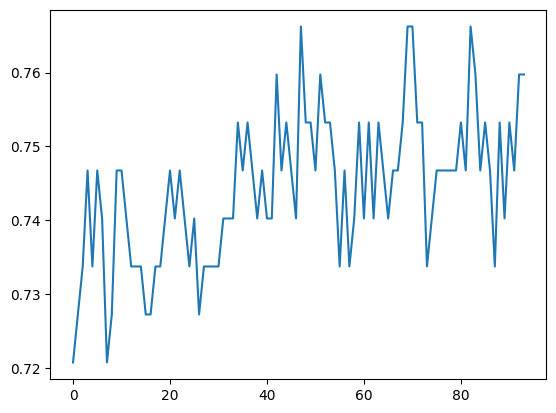

In [54]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])